

# SHL-analys: Samband mellan spelarbudget och lagens prestationer (25/26)

---

## Sammanfattning

notebooken analyserar statistik från SHL-säsongen 25/26 med hjälp av Python, Pandas och Matplotlib. 
Data läses in från en CSV-fil och används för att jämföra lagens spelarbudget med deras prestationer under säsongen, exempelvis antal poäng och tabellplacering.

`Betyder mer pengar framgång?`

---

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset

Datasetet har jag själv tagit fram från Shl´s egna hemsida och bokföring från de olika klubbarna 25/26

---

In [45]:
tabell = pd.read_csv("shl-dataset.csv",sep=",")
print(tabell)

    Rank            Team  SeasonPoints  PointsPerGame  GoalsFor  GoalsAgainst  \
0      1  Skellefteå AIK           108           2.08       182           121   
1      2     Frölunda HC           101           1.94       161           106   
2      3    Växjö Lakers            94           1.81       150           136   
3      4        Rögle BK            93           1.79       155           123   
4      5    Färjestad BK            80           1.54       145           131   
5      6       Brynäs IF            78           1.50       154           143   
6      7  Malmö Redhawks            77           1.48       143           154   
7      8    Luleå Hockey            77           1.48       139           134   
8      9  Djurgårdens IF            73           1.40       136           164   
9     10   Örebro Hockey            66           1.27       139           158   
10    11    Linköping HC            64           1.23       119           148   
11    12        Timrå IK    

### Här går vi igenom om datasetet är rent

---

In [46]:

tabell.isnull().sum()

tabell.duplicated().sum()

tabell.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rank                       14 non-null     int64  
 1   Team                       14 non-null     str    
 2   SeasonPoints               14 non-null     int64  
 3   PointsPerGame              14 non-null     float64
 4   GoalsFor                   14 non-null     int64  
 5   GoalsAgainst               14 non-null     int64  
 6   EstimatedPlayerBudgetMSEK  14 non-null     float64
dtypes: float64(2), int64(4), str(1)
memory usage: 916.0 bytes


Datasetet innehåller inga saknade värden eller dubbletter.

Det betyder att ingen datatvätt krävs innan analysen.

---

## tabellplacering mot spelarbudget

Scatterplot som visar lagens tabellplacering i relation till deras spelarbudget.

Jag har inverterat x axeln för att det blir tydligare

---

[]

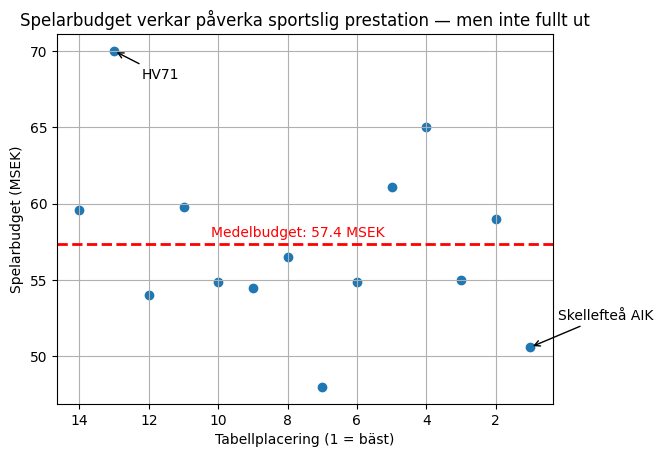

In [92]:
plt.scatter(
  tabell["Rank"],
  tabell["EstimatedPlayerBudgetMSEK"],
)

plt.xlabel("Tabellplacering (1 = bäst)")
plt.ylabel("Spelarbudget (MSEK)")

plt.title(

    "Spelarbudget verkar påverka sportslig prestation — men inte fullt ut"

)
lag1 = tabell[tabell["Rank"] == 1]

lag13 = tabell[tabell["Rank"] == 13]


plt.annotate(
    "Skellefteå AIK",
    (lag1["Rank"].values[0], lag1["EstimatedPlayerBudgetMSEK"].values[0]),
    textcoords="offset points",
    xytext=(20, 20),
    ha="left",
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    "HV71",
    (lag13["Rank"].values[0], lag13["EstimatedPlayerBudgetMSEK"].values[0]),
    textcoords="offset points",
    xytext=(20, -20),
    ha="left",
    arrowprops=dict(arrowstyle="->")
    
)


plt.gca().invert_xaxis()

plt.grid()

#bättre rubriker
#ett linje diagram
medel_budget = tabell["EstimatedPlayerBudgetMSEK"].mean()
plt.annotate(

    f"Medelbudget: {medel_budget:.1f} MSEK",

    xy=(tabell["Rank"].min(), medel_budget),

    xytext=(-230,  5),

    textcoords="offset points",

    color="red"

)

plt.axhline(
    medel_budget,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Medelbudget ({medel_budget:.1f} MSEK)"
)


plt.plot()




Här ser man en liten koppling till att en högre spelarbudget är fördelaktigt för en högre placering men det är fortfarande hyfsat jämt.

`HV71 (plats 13)` underpresterar i relation till budget, medan `Skellefteå (plats 1)` visar hög effektivitet.


---

## Kostnad per poäng

Analysen visar hur mycket spelarbudget varje lag använder för att generera en säsongspoäng.

---

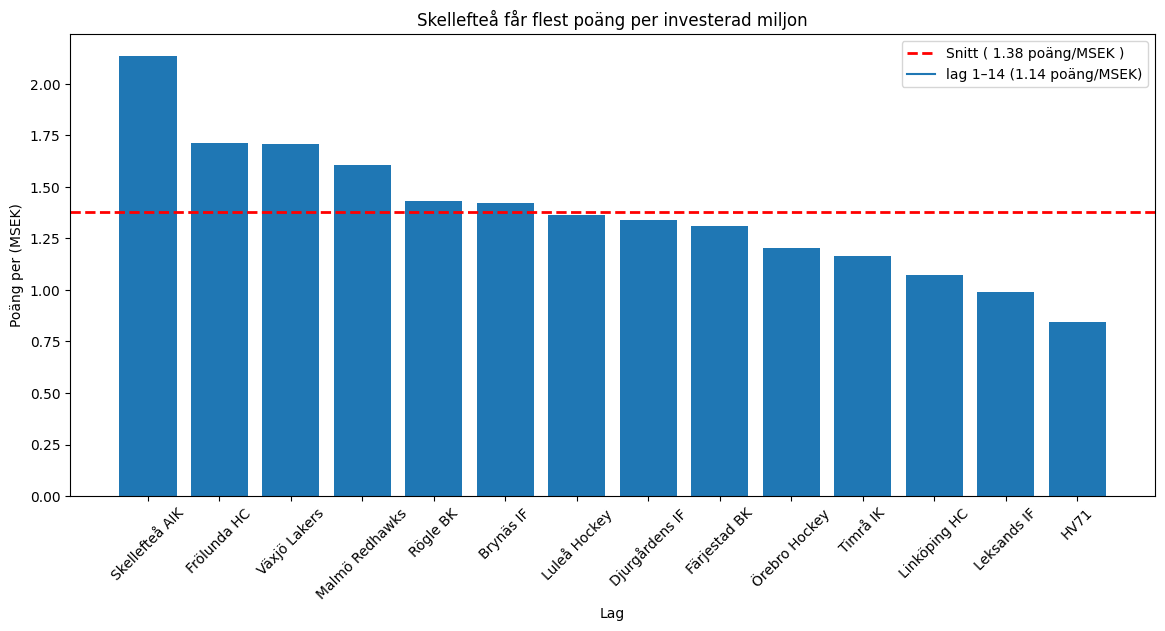

In [ ]:
tabell["PointsPerMSEK"] = (
    tabell["SeasonPoints"] /
    tabell["EstimatedPlayerBudgetMSEK"]
)


effektivitet = tabell.sort_values(
    by="PointsPerMSEK",
    ascending=False
)

plt.figure(figsize=(14,6))

plt.bar(
    effektivitet["Team"],
    effektivitet["PointsPerMSEK"]
)

average_ppm = tabell["PointsPerMSEK"].mean()

plt.axhline(
    average_ppm,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Snitt ( {average_ppm:.2f} poäng/MSEK )"
)

lag1 = tabell[tabell["Rank"] == 1]["PointsPerMSEK"].values[0]
lag14 = tabell[tabell["Rank"] == 14]["PointsPerMSEK"].values[0]

diff = lag1 - lag14

plt.plot([], [], label=f"lag 1–14 ({diff:.2f} poäng/MSEK)")

plt.legend()


plt.legend()

plt.xticks(rotation=45)

plt.ylabel("Poäng per (MSEK)")
plt.xlabel("Lag")

plt.title("Skellefteå får flest poäng per investerad miljon")


plt.show()

Diagrammet visar stora skillnader i kostnadseffektivitet mellan lagen.

Här ser vi att skellefteå sticker ut väldigt mycket jämfört med andra lag. 

---

# Gjorda / Insläppta mål

Diagrammet visar sambandet mellan lagens offensiv (gjorda mål) och defensiv (insläppta mål). Även om det inte direkt visar tabellplacering, går det att identifiera ett tydligt mönster mellan målskillnad och framgång i serien. Det lag som har den bästa statistiken här är inte det lag med mest pengar

---

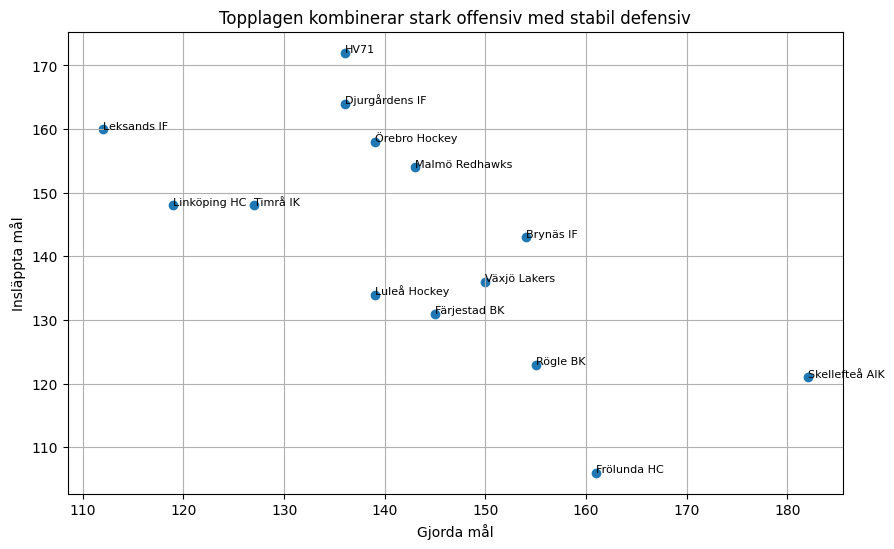

In [49]:
plt.figure(figsize=(10,6))

plt.scatter(
    tabell["GoalsFor"],
    tabell["GoalsAgainst"],
)

# Annotera lag
for i, lag in enumerate(tabell["Team"]):
    plt.annotate(
        lag,
        (
            tabell["GoalsFor"][i],
            tabell["GoalsAgainst"][i]
        ),
        fontsize=8
    )

plt.xlabel("Gjorda mål")
plt.ylabel("Insläppta mål")

plt.title("Topplagen kombinerar stark offensiv med stabil defensiv")

plt.grid()


plt.show()

---

# Sammanfattning

Analysen visar att högre spelarbudget inte automatiskt leder till sportslig framgång i SHL. Det finns en viss positiv relation mellan budget och antal poäng, men sambandet är långt ifrån perfekt. Exempelvis presterade vissa lag med lägre budget bättre än lag med betydligt större ekonomiska resurser.

Skellefteå sticker ut som det mest kostnadseffektiva laget i datasetet genom att kombinera hög poängproduktion med en relativt balanserad budget. Samtidigt visar lag som HV71 att stora investeringar inte garanterar resultat.

Analysen antyder därför att faktorer som lagbygge, tränarstab och gruppdynamik sannolikt också spelar stor roll — något som inte går att mäta direkt i detta dataset.